In [3]:
import os

In [4]:
import matplotlib.pyplot as plt

In [5]:
from PIL import Image

In [6]:
path = '/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/plastic'

In [7]:
image = Image.open(os.path.join(path,os.listdir(path)[3]))

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

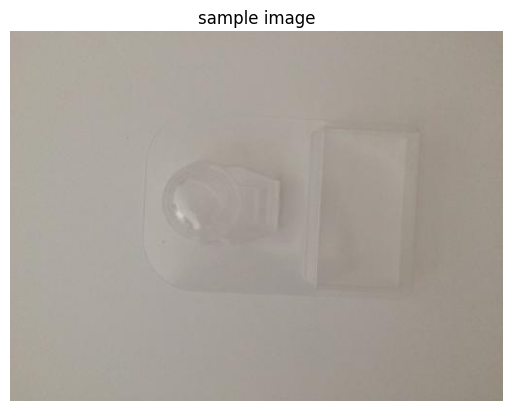

In [8]:
plt.imshow(image)
plt.title('sample image')
plt.axis('off')

In [9]:
path = '/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/glass'

In [10]:
image = Image.open(os.path.join(path,os.listdir(path)[3]))

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

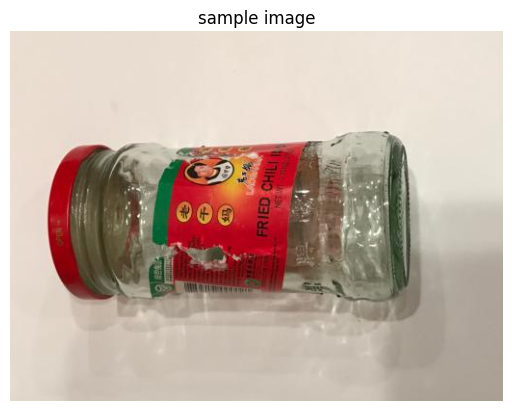

In [11]:
plt.imshow(image)
plt.title('sample image')
plt.axis('off')

In [12]:
dataset_path = '/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized'

In [13]:
classes = os.listdir(dataset_path)

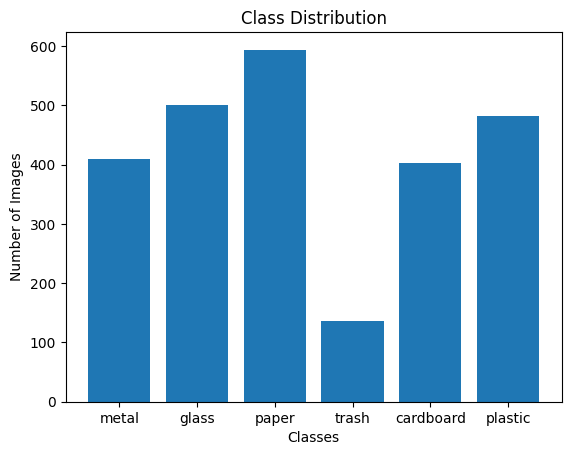

In [14]:
import matplotlib.pyplot as plt

class_counts = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    class_counts.append(len(os.listdir(class_path)))

plt.bar(classes, class_counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [15]:
import tensorflow as tf

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
# in this we applid augmentation because we train model with every possible way of training data and also prevent overfitting

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2,
rotation_range = 20,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

In [18]:
# in this we dont applied augmentation because this is our validation data which help to give accuracy of model

val_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)

In [19]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size = (224,224),
    class_mode='categorical',
    batch_size=32,
    subset = 'training'
)

Found 2024 images belonging to 6 classes.


In [20]:
val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size = (224,224),
    class_mode='categorical',
    batch_size=32,
    subset = 'validation'
)

Found 503 images belonging to 6 classes.


In [21]:
 train_data.class_indices

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

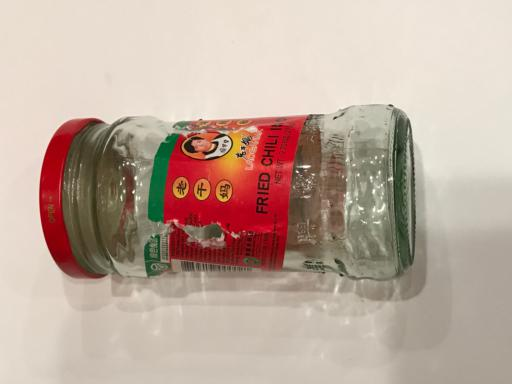

In [22]:
image

In [23]:
!pip install rembg[gpu]

INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 77.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 6.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 102.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 94.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 87.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstal

In [24]:
from rembg import remove

image1 = remove(image)


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

2026-04-03 14:00:09.399592800 [E:onnxruntime:Default, provider_bridge_ort.cc:2359 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /usr/local/lib/python3.12/dist-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory



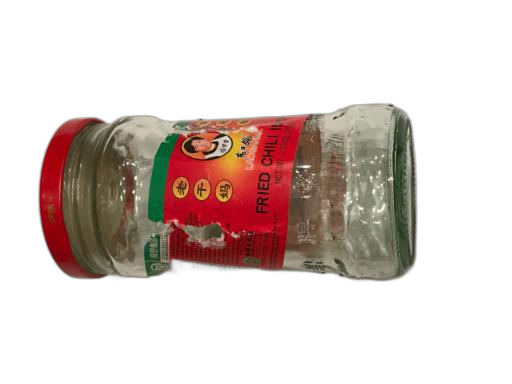

In [25]:
image1

In [26]:
import numpy as np
np.unique(train_data.classes)

array([0, 1, 2, 3, 4, 5], dtype=int32)

In [27]:
from sklearn.utils.class_weight import compute_class_weight


classes = np.unique(train_data.classes)

class_weight = compute_class_weight(class_weight='balanced',
                                   classes=classes,
                                   y=train_data.classes)

class_weight = dict(enumerate(class_weight))



In [28]:
class_weight

{0: np.float64(1.04437564499484),
 1: np.float64(0.8412302576891105),
 2: np.float64(1.0284552845528456),
 3: np.float64(0.7086834733893558),
 4: np.float64(0.8739205526770294),
 5: np.float64(3.066666666666667)}

In [29]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Add custom layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    
    layers.Dropout(0.5),
    
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

2026-04-03 14:00:11.897854: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [31]:
history = model.fit(
    train_data,
    validation_data = val_data,
    epochs = 10,
    class_weight = class_weight
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.4816 - loss: 1.4492 - val_accuracy: 0.7018 - val_loss: 0.7716
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 996ms/step - accuracy: 0.7278 - loss: 0.7444 - val_accuracy: 0.7237 - val_loss: 0.7140
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.7481 - loss: 0.6682 - val_accuracy: 0.7038 - val_loss: 0.8188
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 977ms/step - accuracy: 0.7574 - loss: 0.6163 - val_accuracy: 0.7038 - val_loss: 0.7964
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 970ms/step - accuracy: 0.7735 - loss: 0.6003 - val_accuracy: 0.7475 - val_loss: 0.6276
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 972ms/step - accuracy: 0.8003 - loss: 0.5491 - val_accuracy: 0.7535 - val_loss: 0.7090
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 970ms/step - accuracy: 0.8059 - loss: 0.5037 - val_accuracy: 0.7734 - val_loss: 0.6203
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 981ms/step - accuracy: 0.8282 - loss: 0.4681 - val_accuracy: 

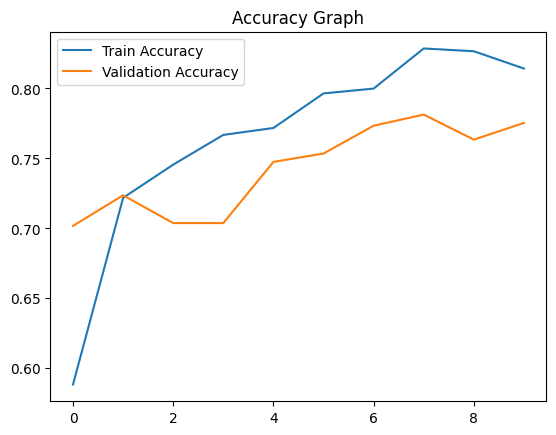

In [33]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Accuracy Graph")
plt.show()

# this graph shows this model is good till 10 epochs after then it show overfitting

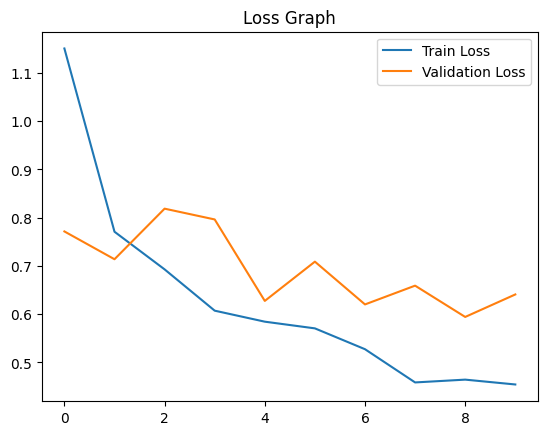

In [34]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [37]:
model.save("/kaggle/working/waste_model.h5")

In [65]:
path = '/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/trash/trash111.jpg'

image = Image.open(os.path.join(path))

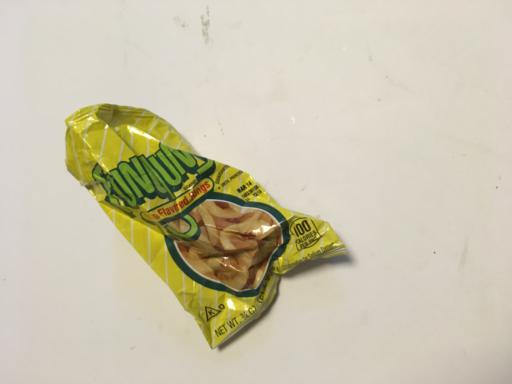

In [66]:
image

In [67]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/trash/trash111.jpg"   # your image path

img = image.load_img(img_path, target_size=(224, 224))

In [68]:
image

<module 'tensorflow.keras.preprocessing.image' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/preprocessing/image/__init__.py'>

In [69]:
import numpy as np
img_array = image.img_to_array(img)

In [70]:
img_array

array([[[217., 212., 208.],
        [217., 212., 208.],
        [217., 212., 208.],
        ...,
        [218., 210., 197.],
        [218., 210., 197.],
        [218., 210., 197.]],

       [[217., 212., 208.],
        [217., 212., 208.],
        [217., 212., 208.],
        ...,
        [218., 210., 197.],
        [218., 210., 197.],
        [218., 210., 197.]],

       [[218., 213., 209.],
        [218., 213., 209.],
        [218., 213., 209.],
        ...,
        [218., 210., 197.],
        [218., 210., 197.],
        [218., 210., 197.]],

       ...,

       [[208., 199., 194.],
        [208., 199., 194.],
        [208., 199., 194.],
        ...,
        [179., 169., 159.],
        [178., 168., 158.],
        [177., 167., 157.]],

       [[208., 199., 194.],
        [208., 199., 194.],
        [208., 199., 194.],
        ...,
        [178., 168., 158.],
        [177., 167., 157.],
        [177., 167., 157.]],

       [[208., 199., 194.],
        [208., 199., 194.],
        [208., 1

In [71]:
img_array = np.expand_dims(img_array, axis=0)

In [72]:
img_array = img_array/255.0

In [73]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [74]:
pred

# In this highest probabily so output is  1 : glass...

array([[0.00127362, 0.01946978, 0.37639898, 0.01483752, 0.16833162,
        0.41968852]], dtype=float32)

In [75]:
print(train_data.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [76]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 52.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pillow
    Found existing installation: pillow 12.2.0
    Uninstalling pillow-12.2.0:
      Successfully uninstalled pillow-12.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rembg 2.0.74 requires pillow<13.0.0,>=12.1.0, but you have pillow 11.3.0 which is incompatible.
ydata-profiling 4.18.1 requires numba<0.63,>=0.60, but you have numba 0.65.0 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 751ms/step


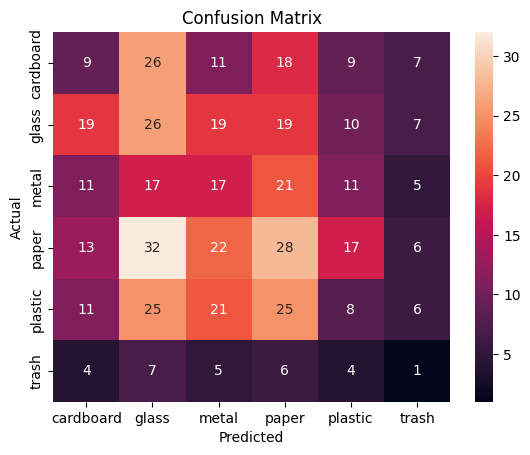

              precision    recall  f1-score   support

   cardboard       0.13      0.11      0.12        80
       glass       0.20      0.26      0.22       100
       metal       0.18      0.21      0.19        82
       paper       0.24      0.24      0.24       118
     plastic       0.14      0.08      0.10        96
       trash       0.03      0.04      0.03        27

    accuracy                           0.18       503
   macro avg       0.15      0.16      0.15       503
weighted avg       0.17      0.18      0.17       503



In [78]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reset generator
val_data.reset()

# Predictions
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = val_data.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [80]:
import gradio as gr
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("waste_model.h5")

class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

def predict_image(img):
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0]

    # Top 3 predictions
    top_indices = pred.argsort()[-3:][::-1]
    
    result = {}
    for i in top_indices:
        result[class_names[i]] = float(pred[i])

    return result

interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="Waste Classification AI",
    description="Upload waste image"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7862
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://47815cefc63a50b3ba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
